# Wicking front against Lucas–Washburn

Loads the results of the 1D wicking cases and follows the **wicking front** over time.

- **Front definition:** the height where the saturation crosses `S_FRONT` (0.1 by default, the leading edge of
  the wetting zone). The saturation drops smoothly over 1–2 mm, so a threshold is needed to define a front.
- **Reference behaviour:** Lucas–Washburn, $h(t) = k\sqrt{t}$ (capillary rise with negligible gravity; here
  $p_{c0}/\rho g \approx 0.5$ m against a 3.4 mm column). $k$ is fitted per case, so the test is the *shape*
  ($h \propto \sqrt{t}$, a straight line through the origin against $\sqrt{t}$), not the absolute rate.

Input per case: `postProcessing/sampleDict/<time>/acrossFlow_*.csv` (saturation profiles, written by
`postProcess -func sampleDict` at the end of `./run`) and `liquidBalance.csv`.

Kernel: the repo's `.venv` (`numpy`, `matplotlib`, `ipykernel`; see `requirements.txt`).

In [19]:
from pathlib import Path
import csv

import numpy as np
import matplotlib.pyplot as plt

# label -> case folder (relative to this notebook)
CASES = {
    "impesFoam": "1D_vertical_impes_inletRes",
    "hybridPorousInterFoam": "1D_vertical_hybrid",
    "yarn hybrid": "singleYarn_vertical_hybrid",
    "yarn impes": "singleYarn_vertical_impes_inletRes",
}

S_FRONT = 0.1    # saturation that defines the wicking front
L_1D = 3.446e-3      # 1D column length [m]
L_YARN = 3.2e-3      # yarn length [m] (xmax - xmin of caseSetup)
LENGTH = {label: L_YARN if case.startswith("singleYarn") else L_1D for label, case in CASES.items()}
L = max(LENGTH.values())    # axis limits
FIT_MAX = 0.9    # Lucas-Washburn fit uses the times where the front is below FIT_MAX*L

In [20]:
# Plot style: one colour and one marker per case, fixed (a case keeps its colour in every figure)
# (impesFoam is drawn larger and first, so it stays visible as a ring where the two cases overlap)
SERIES = {
    "impesFoam": dict(color="#2a78d6", marker="o", markersize=10),
    "hybridPorousInterFoam": dict(color="#eb6834", marker="s", markersize=5.5),
    "yarn hybrid": dict(color="#1baf7a", marker="^", markersize=6),
    "yarn impes": dict(color="#f0c419", marker="v", markersize=6),
}
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
TIME_RAMP = ["#86b6ef", "#6da7ec", "#5598e7", "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.labelcolor": INK2, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.labelsize": 10,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9, "text.color": INK,
    "lines.linewidth": 2, "lines.markersize": 7, "figure.dpi": 110,
})

## Load the results

In [21]:
def load_profiles(case):
    """Saturation profiles of a case: list of (time, y [m], S), sorted by time.
    1D cases: sampleDict line profiles; yarn cases: section-averaged profiles (../sectionProfile.py)."""
    profiles = []
    paths = [*Path(case, "postProcessing", "sampleDict").glob("*/acrossFlow_*.csv"),
             *Path(case, "postProcessing", "sectionProfile").glob("*/alongYarn_*.csv")]
    for path in paths:
        data = np.loadtxt(path, delimiter=",", skiprows=1)
        order = np.argsort(data[:, 0])
        profiles.append((float(path.parent.name), data[order, 0], data[order, 1]))
    if not profiles:
        raise FileNotFoundError(f"no sampleDict/sectionProfile profiles in {case}: run the case (./run) first")
    return sorted(profiles, key=lambda p: p[0])


def load_balance(case):
    """liquidBalance.csv as a dict of arrays (time, volume [mL], mass [g], mean saturation)."""
    with open(Path(case, "liquidBalance.csv")) as f:
        rows = list(csv.reader(f))
    data = np.array(rows[1:], dtype=float)
    return {name: data[:, i] for i, name in enumerate(rows[0])}


profiles = {label: load_profiles(case) for label, case in CASES.items()}
balance = {label: load_balance(case) for label, case in CASES.items()}

for label, prof in profiles.items():
    times = [t for t, _, _ in prof]
    print(f"{label:24s} {len(prof)} profiles, t = {min(times):g} to {max(times):g} s, {len(prof[0][1])} points each")

impesFoam                21 profiles, t = 0 to 0.1 s, 171 points each
hybridPorousInterFoam    21 profiles, t = 0 to 0.1 s, 171 points each
yarn hybrid              21 profiles, t = 0 to 0.1 s, 64 points each
yarn impes               21 profiles, t = 0 to 0.1 s, 64 points each


## Saturation profiles and the front definition

The dashed line is `S_FRONT`. The front at each time is where the profile crosses it.

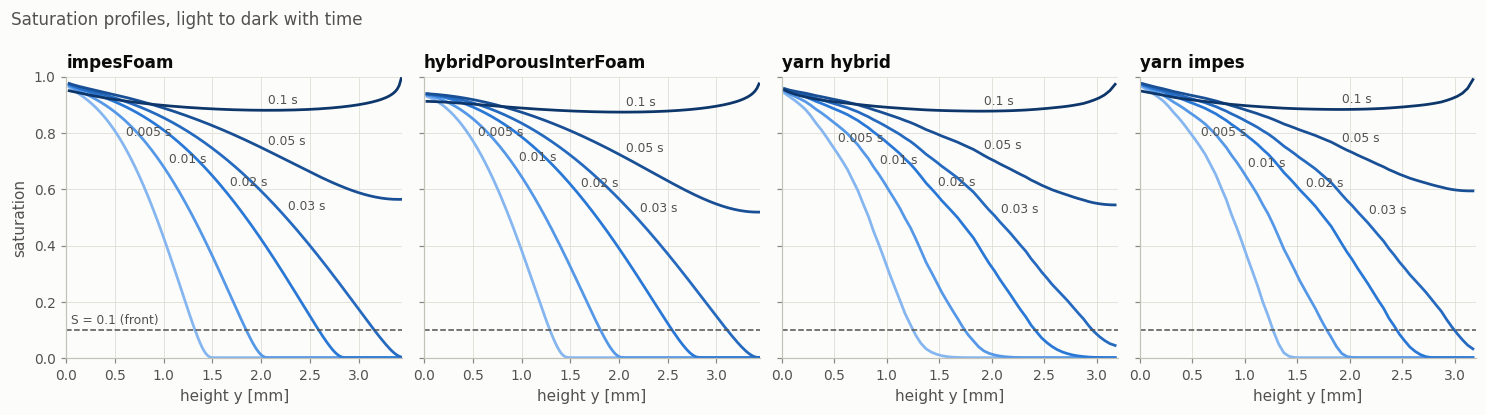

In [22]:
shown = [0.005, 0.01, 0.02, 0.03, 0.05, 0.1]

fig, axes = plt.subplots(1, len(CASES), figsize=(3.4*len(CASES), 3.8), sharey=True)
for ax, (label, prof) in zip(axes, profiles.items()):
    picked = [p for p in prof if any(np.isclose(p[0], s) for s in shown)]
    colours = [TIME_RAMP[round(i*(len(TIME_RAMP) - 1)/max(len(picked) - 1, 1))] for i in range(len(picked))]
    levels = np.linspace(0.78, 0.34, len(picked))     # staggered so the labels do not collide
    for (t, y, S), c, level in zip(picked, colours, levels):
        ax.plot(y*1e3, S, color=c, lw=1.8)
        # label each curve with its time where it crosses its level (or at the top if it never does)
        below = np.where(S < level)[0]
        if len(below):
            i = below[0]
            ax.annotate(f"{t:g} s", (y[i]*1e3, S[i]), xytext=(4, 2), textcoords="offset points",
                        fontsize=8, color=INK2)
        else:
            i = np.searchsorted(y, 0.6*LENGTH[label])
            ax.annotate(f"{t:g} s", (y[i]*1e3, S[i]), xytext=(0, 4), textcoords="offset points",
                        fontsize=8, color=INK2)
    ax.axhline(S_FRONT, color=INK2, lw=1, ls="--")
    ax.set_title(label)
    ax.set_xlabel("height y [mm]")
    ax.set_xlim(0, LENGTH[label]*1e3)
    ax.set_ylim(0, 1)
axes[0].set_ylabel("saturation")
axes[0].annotate(f"S = {S_FRONT:g} (front)", (0.05, S_FRONT), xytext=(0, 4), textcoords="offset points",
                 fontsize=8, color=INK2)
fig.suptitle("Saturation profiles, light to dark with time", x=0.01, ha="left", fontsize=11, color=INK2)
fig.tight_layout()
plt.show()

## Front position over time

In [23]:
def front_position(y, S, threshold):
    """Highest height where S crosses the threshold (linear interpolation).
    NaN if the whole column is above the threshold (front past the top) or below it."""
    above = np.where(S >= threshold)[0]
    if len(above) == 0 or above[-1] == len(S) - 1:
        return np.nan
    i = above[-1]
    return y[i] + (S[i] - threshold)/(S[i] - S[i + 1])*(y[i + 1] - y[i])


def arrival_time(prof, threshold):
    """Time at which the top of the column reaches the threshold (linear interpolation in time)."""
    t = np.array([p[0] for p in prof])
    S_top = np.array([p[2][-1] for p in prof])
    reached = np.where(S_top >= threshold)[0]
    if len(reached) == 0 or reached[0] == 0:
        return np.nan
    i = reached[0]
    return t[i - 1] + (threshold - S_top[i - 1])/(S_top[i] - S_top[i - 1])*(t[i] - t[i - 1])


front = {}
for label, prof in profiles.items():
    t = np.array([p[0] for p in prof])
    h = np.array([front_position(y, S, S_FRONT) for _, y, S in prof])
    front[label] = (t, h)

labels = list(CASES)
print(f"Front height [mm] at S = {S_FRONT:g}")
print("   t [s]  " + "".join(f"{lab:>24s}" for lab in labels))
for i, t in enumerate(front[labels[0]][0]):
    row = "".join(f"{front[lab][1][i]*1e3:24.3f}" if np.isfinite(front[lab][1][i]) else f"{'past the top':>24s}"
                  for lab in labels)
    print(f"  {t:6.3f}  {row}")
    if not any(np.isfinite(front[lab][1][i]) for lab in labels):
        break    # every case is past the top from here on
print("(t = 0 is the prewetted ramp of the initial state)")

Front height [mm] at S = 0.1
   t [s]                 impesFoam   hybridPorousInterFoam             yarn hybrid              yarn impes
   0.000                     0.180                   0.180                   0.196                   0.196
   0.005                     1.321                   1.291                   1.251                   1.271
   0.010                     1.846                   1.810                   1.743                   1.783
   0.015                     2.250                   2.209                   2.104                   2.143
   0.020                     2.590                   2.545                   2.413                   2.450
   0.025                     2.889                   2.842                   2.702                   2.756
   0.030                     3.160                   3.110                   2.960                   2.998
   0.035              past the top            past the top            past the top            past the top
(t = 0 i

## Lucas–Washburn fit

$h = k\sqrt{t}$ fitted by least squares through the origin, on the times where the front is still below
`FIT_MAX`·L (the law holds for a column that is long compared with the front position). t = 0 is left out: the
front there is the prewetted ramp of the initial state.

In [24]:
fit = {}
print(f"{'case':24s} {'k [mm/sqrt(s)]':>15s} {'points':>7s} {'max deviation':>14s} {'top reached: fit':>17s} {'run':>9s}")
for label, (t, h) in front.items():
    use = np.isfinite(h) & (h < FIT_MAX*LENGTH[label]) & (t > 0)
    k = np.sum(h[use]*np.sqrt(t[use]))/np.sum(t[use])
    deviation = np.max(np.abs(h[use]/(k*np.sqrt(t[use])) - 1))
    t_fit = (LENGTH[label]/k)**2
    t_run = arrival_time(profiles[label], S_FRONT)
    fit[label] = dict(k=k, use=use, t_top_fit=t_fit, t_top_run=t_run)
    print(f"{label:24s} {k*1e3:15.2f} {use.sum():7d} {deviation*100:13.1f}% {t_fit:15.4f} s {t_run:7.4f} s")

case                      k [mm/sqrt(s)]  points  max deviation  top reached: fit       run
impesFoam                          18.35       5           1.8%          0.0352 s  0.0333 s
hybridPorousInterFoam              18.03       5           1.3%          0.0365 s  0.0344 s
yarn hybrid                        17.19       5           2.9%          0.0347 s  0.0323 s
yarn impes                         17.51       5           2.7%          0.0334 s  0.0321 s


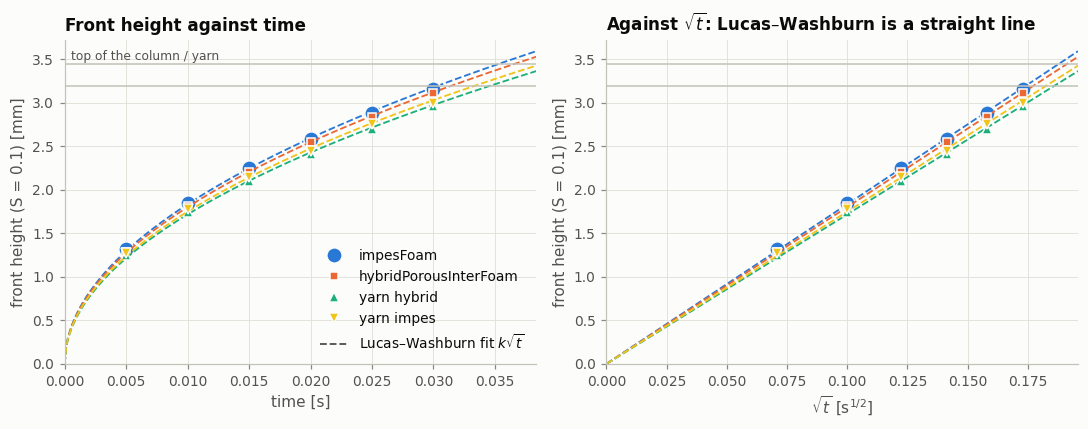

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

t_line = np.linspace(0, max(f["t_top_fit"] for f in fit.values())*1.05, 300)
for label, (t, h) in front.items():
    style, k = SERIES[label], fit[label]["k"]
    ok = np.isfinite(h) & (t > 0)
    marks = dict(ls="none", marker=style["marker"], markersize=style["markersize"], color=style["color"],
                 markeredgecolor=SURFACE, markeredgewidth=1.0, label=label)
    # Lucas-Washburn fit (thin dashed line) and the run (markers)
    ax1.plot(t_line, k*np.sqrt(t_line)*1e3, color=style["color"], lw=1.2, ls="--")
    ax1.plot(t[ok], h[ok]*1e3, **marks)
    ax2.plot(np.sqrt(t_line), k*np.sqrt(t_line)*1e3, color=style["color"], lw=1.2, ls="--")
    ax2.plot(np.sqrt(t[ok]), h[ok]*1e3, **marks)

for ax in (ax1, ax2):
    for length in set(LENGTH.values()):
        ax.axhline(length*1e3, color=AXIS, lw=1)
    ax.set_ylim(0, L*1e3*1.08)
    ax.set_ylabel(f"front height (S = {S_FRONT:g}) [mm]")
ax1.annotate("top of the column / yarn", (0, L*1e3), xytext=(4, 3), textcoords="offset points", fontsize=8, color=INK2)
ax1.set_xlim(0, t_line[-1]); ax1.set_xlabel("time [s]")
ax1.set_title("Front height against time")
ax2.set_xlim(0, np.sqrt(t_line[-1])); ax2.set_xlabel(r"$\sqrt{t}$ [s$^{1/2}$]")
ax2.set_title(r"Against $\sqrt{t}$: Lucas–Washburn is a straight line")

handles, names = ax1.get_legend_handles_labels()
handles.append(plt.Line2D([], [], color=INK2, lw=1.2, ls="--")); names.append(r"Lucas–Washburn fit $k\sqrt{t}$")
ax1.legend(handles, names, loc="lower right")
fig.tight_layout()
plt.show()

## Is $h/\sqrt{t}$ constant?

Lucas–Washburn means $h/\sqrt{t} = k$ at every time. The table shows the ratio at each output time.

In [26]:
print("h/sqrt(t) [mm/sqrt(s)]")
print("   t [s]  " + "".join(f"{lab:>24s}" for lab in labels))
for i, t in enumerate(front[labels[0]][0]):
    if t == 0 or not any(np.isfinite(front[lab][1][i]) for lab in labels):
        continue
    cells = []
    for lab in labels:
        h = front[lab][1][i]
        cells.append(f"{h/np.sqrt(t)*1e3:24.2f}" if np.isfinite(h) else f"{'-':>24s}")
    print(f"  {t:6.3f}  " + "".join(cells))
print("  fit k   " + "".join(f"{fit[lab]['k']*1e3:24.2f}" for lab in labels))

h/sqrt(t) [mm/sqrt(s)]
   t [s]                 impesFoam   hybridPorousInterFoam             yarn hybrid              yarn impes
   0.005                     18.68                   18.26                   17.69                   17.98
   0.010                     18.46                   18.10                   17.43                   17.83
   0.015                     18.37                   18.03                   17.18                   17.50
   0.020                     18.31                   18.00                   17.06                   17.32
   0.025                     18.27                   17.97                   17.09                   17.43
   0.030                     18.24                   17.95                   17.09                   17.31
  fit k                      18.35                   18.03                   17.19                   17.51


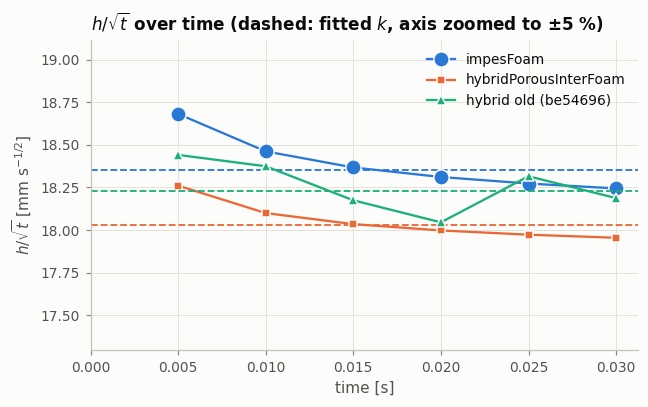

In [9]:
# Same ratio as a plot: the two cases overlap in the figure above, the differences show here.
# The y axis is zoomed on the ratio (it does not start at 0).
fig, ax = plt.subplots(figsize=(6, 3.8))
for label, (t, h) in front.items():
    style, k = SERIES[label], fit[label]["k"]
    ok = np.isfinite(h) & (t > 0)
    ax.axhline(k*1e3, color=style["color"], lw=1.2, ls="--")
    ax.plot(t[ok], h[ok]/np.sqrt(t[ok])*1e3, marker=style["marker"], markersize=style["markersize"],
            color=style["color"], markeredgecolor=SURFACE, markeredgewidth=1.0, lw=1.5, label=label)
k_mean = np.mean([f["k"] for f in fit.values()])*1e3
ax.set_ylim(k_mean*0.95, k_mean*1.05)
ax.set_xlim(0, None)
ax.set_xlabel("time [s]"); ax.set_ylabel(r"$h/\sqrt{t}$ [mm s$^{-1/2}$]")
ax.set_title(r"$h/\sqrt{t}$ over time (dashed: fitted $k$, axis zoomed to ±5 %)")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

## Uptake

Mean saturation of the column (from `liquidBalance.csv`). It also follows $\sqrt{t}$ until the front reaches the
top, then levels off.

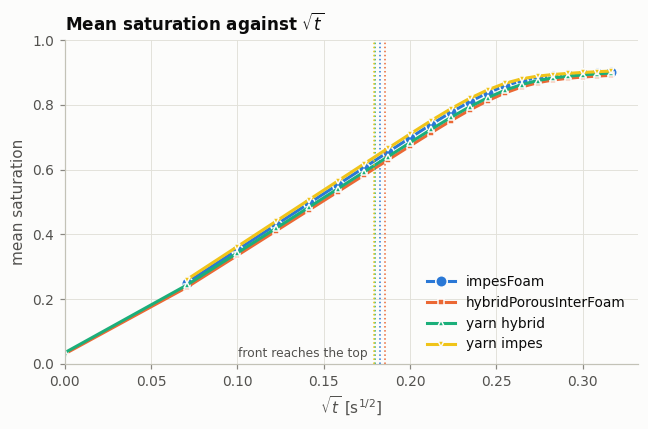

In [27]:
fig, ax = plt.subplots(figsize=(6, 4))
for label, bal in balance.items():
    style = SERIES[label]
    ax.plot(np.sqrt(bal["time"]), bal["meanSaturation"], marker=style["marker"], color=style["color"],
            markeredgecolor=SURFACE, markeredgewidth=1.0, markersize=style["markersize"]*0.75, label=label)
    t_top = fit[label]["t_top_run"]
    if np.isfinite(t_top):
        ax.axvline(np.sqrt(t_top), color=style["color"], lw=1, ls=":")
ax.annotate("front reaches the top", (np.sqrt(min(f["t_top_run"] for f in fit.values())), 0.02),
            xytext=(-4, 0), textcoords="offset points", ha="right", fontsize=8, color=INK2)
ax.set_xlim(0, None); ax.set_ylim(0, 1)
ax.set_xlabel(r"$\sqrt{t}$ [s$^{1/2}$]"); ax.set_ylabel("mean saturation")
ax.set_title(r"Mean saturation against $\sqrt{t}$")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

## Notes

- Only the output times written by the runs are available (`writeInterval` in `system/controlDict`, 0.005 s),
  so the front is followed on a handful of points before it reaches the top. Lower `writeInterval` and rerun
  for a finer curve.
- To use another threshold, change `S_FRONT` and rerun the notebook. To add a case, add it to `CASES` (and to
  `SERIES` for its colour); the profile file is found by pattern, so the field name does not matter.
- $k$ is fitted, not predicted: this checks the $\sqrt{t}$ law, not the absolute wicking rate.
- `hybrid old (be54696)` is the same hybrid case computed with the solver before the porous-face changes
  (`hybridSolverChanges/`); its profiles and `liquidBalance.csv` are kept in `1D_vertical_hybrid/results_be54696/`
  (the profiles are local only: `postProcessing/` is not in git).